Converged in 40 iterations.

Node       | Custom Points   | Inbuilt Rank Value
--------------------------------------------------
1          | 159.9999        | 0.4000
3          | 159.9999        | 0.4000
2          | 80.0001         | 0.2000
4          | 0.0000          | 0.0000


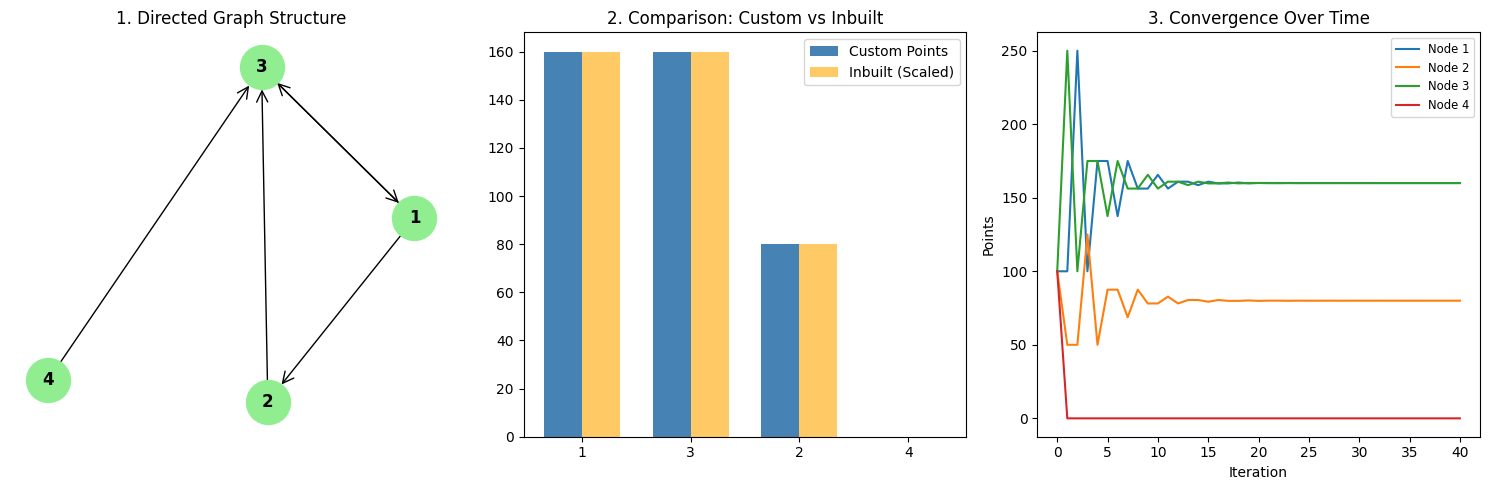

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def pagerank_points_distribution(G, initial_points=100, tolerance=0.001):
    """
    Step-by-step PageRank implementation with History Tracking.
    Formula: P_new(j) = Σ (P_old(i) / Out-degree(i))
    """
    nodes = sorted(list(G.nodes()))
    n = len(nodes)

    # Step 2: Assign 100 points to each node
    current_points = {node: float(initial_points) for node in nodes}

    # history stores points at each iteration for the convergence plot
    history = [current_points.copy()]
    iteration = 0
    converged = False

    # Step 3: Keep distributing points until convergence
    while not converged:
        new_points = {node: 0.0 for node in nodes}
        for node in nodes:
            out_degree = G.out_degree(node)
            if out_degree > 0:
                share = current_points[node] / out_degree
                for neighbor in G.successors(node):
                    new_points[neighbor] += share
            else:
                # Sink node handling
                for any_node in nodes:
                    new_points[any_node] += current_points[node] / n

        # Check convergence
        diff = sum(abs(new_points[node] - current_points[node]) for node in nodes)
        current_points = new_points.copy()
        history.append(current_points.copy())
        iteration += 1

        if diff < tolerance or iteration > 100:
            break

    return current_points, history, iteration

# --- STEP 4: Create the Graph ---
G = nx.DiGraph()
G.add_edges_from([(1, 2), (1, 3), (2, 3), (3, 1), (4, 3)])

# --- EXECUTE CUSTOM METHOD ---
final_points, history, total_iters = pagerank_points_distribution(G)

# --- STEP 5: COMPARE & SCALE ---
inbuilt_ranks = nx.pagerank(G, alpha=1.0)
# Scaling inbuilt (0.0 - 1.0) to match custom points (e.g., 0 - 400)
total_points_in_system = len(G.nodes()) * 100
inbuilt_scaled = {node: val * total_points_in_system for node, val in inbuilt_ranks.items()}

# --- PRINT TERMINAL TABLE ---
print(f"Converged in {total_iters} iterations.\n")
print(f"{'Node':<10} | {'Custom Points':<15} | {'Inbuilt Rank Value'}")
print("-" * 50)
sorted_nodes = sorted(final_points.keys(), key=lambda x: final_points[x], reverse=True)
for node in sorted_nodes:
    print(f"{node:<10} | {final_points[node]:<15.4f} | {inbuilt_ranks[node]:.4f}")

# --- VISUALIZATIONS ---
plt.figure(figsize=(15, 5))

# Plot 1: Graph Visualization
plt.subplot(1, 3, 1)
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightgreen', node_size=1000,
        arrowstyle='->', arrowsize=20, font_weight='bold')
plt.title("1. Directed Graph Structure")

# Plot 2: Comparison Bar Chart (The Scaled Proof)
plt.subplot(1, 3, 2)
x = np.arange(len(sorted_nodes))
width = 0.35
custom_vals = [final_points[n] for n in sorted_nodes]
scaled_vals = [inbuilt_scaled[n] for n in sorted_nodes]

plt.bar(x - width/2, custom_vals, width, label='Custom Points', color='steelblue')
plt.bar(x + width/2, scaled_vals, width, label='Inbuilt (Scaled)', color='orange', alpha=0.6)
plt.xticks(x, sorted_nodes)
plt.title("2. Comparison: Custom vs Inbuilt")
plt.legend()

# Plot 3: Convergence History
plt.subplot(1, 3, 3)
history_df = pd.DataFrame(history)
for node in history_df.columns:
    plt.plot(history_df.index, history_df[node], label=f"Node {node}")
plt.title("3. Convergence Over Time")
plt.xlabel("Iteration")
plt.ylabel("Points")
plt.legend(loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()